In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

import rasterio
from rasterio.mask import mask
from rasterio.transform import array_bounds
import osmnx as ox

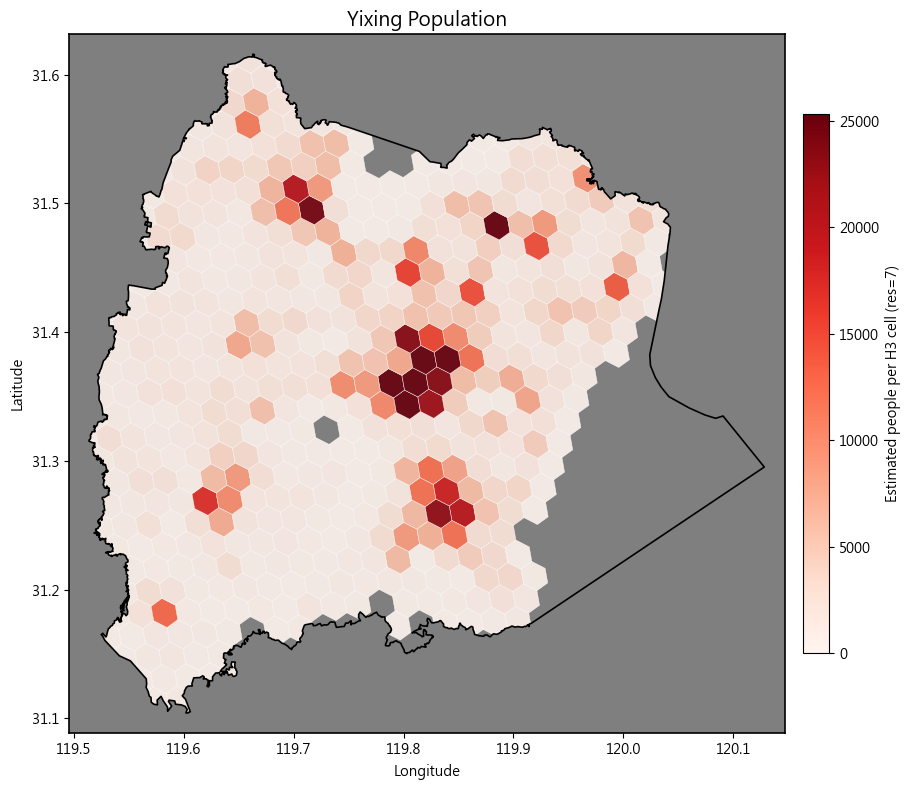

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import rasterio
from rasterio.mask import mask
from rasterio.transform import xy as transform_xy

import osmnx as ox
import geopandas as gpd
from shapely.geometry import Polygon
from pyproj import Transformer

import h3


# 1) H3 API 相容（新/舊版 h3 套件）
# ---------------------------
def latlon_to_h3(lat, lon, res: int) -> str:
    # 新版 h3: latlng_to_cell
    if hasattr(h3, "latlng_to_cell"):
        return h3.latlng_to_cell(lat, lon, res)
    # 舊版 h3: geo_to_h3
    return h3.geo_to_h3(lat, lon, res)


def h3_to_polygon(h3_id: str) -> Polygon:
    # 新版 h3: cell_to_boundary 回傳 (lat, lon)
    if hasattr(h3, "cell_to_boundary"):
        boundary = h3.cell_to_boundary(h3_id)  # [(lat, lon), ...]
        return Polygon([(lon, lat) for lat, lon in boundary])
    # 舊版 h3: h3_to_geo_boundary(geo_json=True) 回傳 (lon, lat)
    boundary = h3.h3_to_geo_boundary(h3_id, geo_json=True)  # [(lon, lat), ...]
    return Polygon(boundary)


# ---------------------------
# 2) 輸入：你的 WorldPop tif
# ---------------------------
tif_path = r"Yixing_data\chn_pop_2024_CN_100m_R2025A_v1.tif"

# H3 網格解析度
H3_RES = 7

# 3) 取宜興邊界（OSM）
districts = ox.geocode_to_gdf(["Yixing, Wuxi, Jiangsu, China"]).set_crs("EPSG:4326", allow_override=True)

# 4) 讀 raster + 用邊界裁剪
with rasterio.open(tif_path) as src:
    # 把邊界投影到 raster CRS 才能 mask
    districts_r = districts.to_crs(src.crs)

    out, out_transform = mask(src, districts_r.geometry, crop=True)
    data = out[0].astype(np.float32)

    # NoData -> NaN（保留 0，因為 0 是「0 人」）
    if src.nodata is not None:
        data[data == src.nodata] = np.nan

    # 建立座標轉換：raster CRS -> WGS84
    # H3 需要 EPSG:4326 的 (lat, lon)
    transformer = Transformer.from_crs(src.crs, "EPSG:4326", always_xy=True)

# 5) 只取有效像元（>0 的才需要丟進 H3，加快很多）
valid = np.isfinite(data) & (data > 0)
rows, cols = np.where(valid)
vals = data[rows, cols]

# 6) 像元中心座標（先在 raster CRS）
xs, ys = transform_xy(out_transform, rows, cols, offset="center")
xs = np.asarray(xs)
ys = np.asarray(ys)

# 7) 轉成經緯度（lon, lat）
lons, lats = transformer.transform(xs, ys)

# 8) 投到 H3 cell，並加總人口
h3_ids = [latlon_to_h3(lat, lon, H3_RES) for lat, lon in zip(lats, lons)]
df = pd.DataFrame({"id": h3_ids, "pop": vals})
agg = df.groupby("id", as_index=False)["pop"].sum()

# 9) 轉成 GeoDataFrame（H3 六角形）+ clip 到宜興邊界
agg["geometry"] = agg["id"].apply(h3_to_polygon)
gdf_h3 = gpd.GeoDataFrame(agg, geometry="geometry", crs="EPSG:4326")
gdf_h3_clipped = gpd.clip(gdf_h3, districts)

# 10) 畫圖（像你貼的 SVR 圖：灰底、方框、經緯度）
total_pop = gdf_h3_clipped["pop"].sum()

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor("#7f7f7f")  # 灰底，接近你示例圖

# 設定畫面範圍（用宜興邊界 bounds）
minx, miny, maxx, maxy = districts.total_bounds
pad_x = (maxx - minx) * 0.03
pad_y = (maxy - miny) * 0.03
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

# 六角網格：白邊框 + 紅色填色
vmax = np.nanpercentile(gdf_h3_clipped["pop"].values, 99)

gdf_h3_clipped.plot(
    column="pop",
    ax=ax,
    cmap="Reds",
    alpha=0.9,
    edgecolor="white",     # ✅ 六角白邊
    linewidth=0.35,        # ✅ 邊線粗細像示例
    vmin=0,
    vmax=vmax,
    zorder=2
)

# （可選）畫行政邊界：黑色外框
districts.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.2,
    zorder=3
)

# ✅ 方框：確保 spines 打開 + 加粗
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color("black")

# ✅ 經緯度標籤
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# ✅ 標題
ax.set_title(f"Yixing Population", fontsize=14)

# ✅ Colorbar（自己建，效果更像示例）
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=0, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="Reds", norm=norm)
sm.set_array([])  # 必要
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label(f"Estimated people per H3 cell (res={H3_RES})")

plt.tight_layout()
plt.show()


In [16]:
np.nanpercentile(data, (50, 90, 99, 99.9, 100))

array([  2.33937454,  23.59893551,  75.24053726, 103.39762241,
       123.42369843])